## Visualisasi Perbandingan Skenario


In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams["figure.figsize"] = (10, 6)

### Load Dataset

In [54]:
SUMMARY_PATH = "manual_tuning_summary.csv"

df = pd.read_csv(SUMMARY_PATH, sep=";", encoding="utf-8-sig")

print(f"Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Jumlah data: 1600 baris, 18 kolom


,scenario_group,K,alpha,beta,gamma,lambda_umkm,sold_weight,review_weight,rating_weight,discount_weight,Precision,Recall,F1_score,NDCG,Fairness,Unjudged@K,Relevant@K,Judged@K
0,balanced,10,0.34,0.33,0.33,0.03,0.40,0.60,0.40,0.60,0.78,0.11,0.19,0.81,1.00,0.00,7.83,10.00
1,balanced,10,0.34,0.33,0.33,0.03,0.40,0.60,0.50,0.50,0.80,0.11,0.19,0.83,1.00,0.00,8.00,10.00
2,balanced,10,0.34,0.33,0.33,0.03,0.40,0.60,0.60,0.40,0.78,0.11,0.19,0.81,1.00,0.00,7.83,10.00
3,balanced,10,0.34,0.33,0.33,0.03,0.40,0.60,0.70,0.30,0.78,0.11,0.19,0.81,1.00,0.00,7.83,10.00
4,balanced,10,0.34,0.33,0.33,0.03,0.50,0.50,0.40,0.60,0.78,0.11,0.19,0.81,1.00,0.00,7.83,10.00


### Ringkasan Rata-rata Metrik


In [55]:
metrics = ["Precision", "Recall", "F1_score", "NDCG", "Fairness"]
    
summary = (
    df.groupby("scenario_group", observed=True)[metrics]
    .mean()
    .reset_index()
)

summary

,scenario_group,Precision,Recall,F1_score,NDCG,Fairness
0,balanced,0.72,0.28,0.38,0.75,1.00
1,popularity_dominant,0.68,0.27,0.36,0.71,1.00
2,relevance_dominant,0.74,0.30,0.40,0.78,1.00
3,value_dominant,0.68,0.27,0.36,0.72,1.00


### Heatmap Rata-rata Metrik

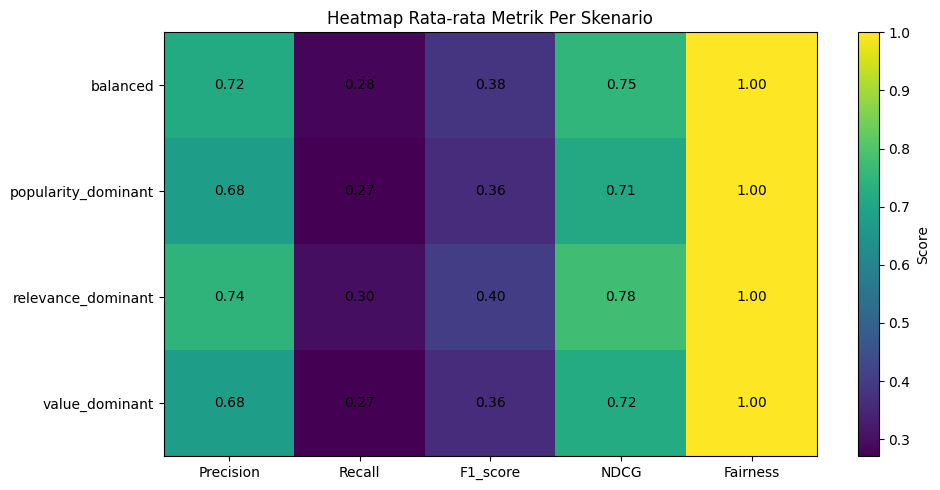

In [58]:
heatmap_data = summary.set_index("scenario_group")[metrics]

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_data, aspect="auto")

plt.xticks(np.arange(len(metrics)), metrics)
plt.yticks(np.arange(len(heatmap_data.index)), heatmap_data.index)

plt.title("Heatmap Rata-rata Metrik Per Skenario")
plt.colorbar(label="Score")

for i in range(len(heatmap_data.index)):
    for j in range(len(metrics)):
        plt.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()